# VNFood Baseline Comparison Notebook

Notebook này dùng để train thêm các baseline **single-model classifier** trên toàn bộ dataset VNFood để so sánh với pipeline hierarchical hiện tại:

- Hierarchical: EfficientNet-B0 group classifier + EfficientNet-B2 sub-class classifiers
- Single EfficientNet-B0 trên 103 class
- Single EfficientNet-B2 trên 103 class
- Single ConvNeXt-Tiny trên 103 class
- Simple CNN baseline trên 103 class

Output chính:

- `baseline_epoch_metrics.csv`
- `baseline_final_metrics.csv`
- `baseline_test_metrics.csv`
- `baseline_metrics_summary.xlsx`
- checkpoint tốt nhất của từng model


In [1]:
# ============================================================
# 1. IMPORTS & SETUP
# ============================================================

import os
import random
import time
import json
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    efficientnet_b2, EfficientNet_B2_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights,
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from tqdm import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

DATA_DIR = Path('/kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(exist_ok=True)

# Nếu muốn chạy thử nhanh, giảm các epoch này xuống 1-2.
BATCH_SIZE = 32
NUM_WORKERS = 2
DROPOUT = 0.3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

# Transfer learning schedule cho pretrained models
PHASE1_EPOCHS = 5      # train classifier head only
PHASE1_LR = 1e-3
PHASE2_EPOCHS = 10     # unfreeze top blocks
PHASE2_LR = 1e-4
PHASE3_EPOCHS = 15     # full fine-tune
PHASE3_LR = 5e-5

# Simple CNN thường train from scratch, có thể cần epoch riêng
CNN_EPOCHS = 30
CNN_LR = 1e-3

# Chọn model muốn train. Có thể bật/tắt để tiết kiệm thời gian.
RUN_MODELS = {
    # 'single_effb0': True,
    # 'single_effb2': True,
    'single_convnext_tiny': True,
    'simple_cnn': True,
}

IMG_SIZE_BY_MODEL = {
    # 'single_effb0': 224,
    # 'single_effb2': 260,
    'single_convnext_tiny': 224,
    'simple_cnn': 224,
}

print('Paths:')
print('Train:', TRAIN_DIR)
print('Val  :', VAL_DIR)
print('Test :', TEST_DIR)
print('Output:', OUTPUT_DIR)


Paths:
Train: /kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset/train
Val  : /kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset/val
Test : /kaggle/input/datasets/meowluvmatcha/vnfood-30-100/vnfood_combined_dataset/test
Output: /kaggle/working


In [3]:
# ============================================================
# 3. DATASET CHECK
# ============================================================

assert TRAIN_DIR.exists(), f'Missing train dir: {TRAIN_DIR}'
assert VAL_DIR.exists(), f'Missing val dir: {VAL_DIR}'
assert TEST_DIR.exists(), f'Missing test dir: {TEST_DIR}'

class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
num_classes = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

print(f'Number of classes: {num_classes}')
print('First 10 classes:', class_names[:10])

# Kiểm tra class giữa train/val/test có khớp không
for split_name, split_dir in [('val', VAL_DIR), ('test', TEST_DIR)]:
    split_classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    missing = sorted(set(class_names) - set(split_classes))
    extra = sorted(set(split_classes) - set(class_names))
    print(f'{split_name}: {len(split_classes)} classes | missing={len(missing)} | extra={len(extra)}')
    if missing[:5]: print('  missing sample:', missing[:5])
    if extra[:5]: print('  extra sample:', extra[:5])


Number of classes: 103
First 10 classes: ['baba-nau-chuoi-dau', 'banh-bao', 'banh-beo', 'banh-bo', 'banh-bot-loc', 'banh-can', 'banh-canh', 'banh-chung', 'banh-cong', 'banh-cuon']
val: 103 classes | missing=0 | extra=0
test: 103 classes | missing=0 | extra=0


In [4]:
# ============================================================
# 4. TRANSFORMS & DATALOADERS
# ============================================================

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def get_transforms(img_size):
    train_tf = transforms.Compose([
        transforms.Resize((img_size + 20, img_size + 20)),
        transforms.RandomCrop(img_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        transforms.RandomGrayscale(p=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])
    return train_tf, eval_tf


def make_loaders(img_size, batch_size=BATCH_SIZE):
    train_tf, eval_tf = get_transforms(img_size)

    train_ds = ImageFolder(TRAIN_DIR, transform=train_tf)
    val_ds   = ImageFolder(VAL_DIR, transform=eval_tf)
    test_ds  = ImageFolder(TEST_DIR, transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

# Quick check với EfficientNet-B0 size
_tmp = make_loaders(224)
print(f'Train samples: {len(_tmp[0])}')
print(f'Val samples  : {len(_tmp[1])}')
print(f'Test samples : {len(_tmp[2])}')
del _tmp


Train samples: 34456
Val samples  : 7383
Test samples : 7384


In [5]:
# ============================================================
# 5. MODEL BUILDERS
# ============================================================


def build_single_effb0(num_classes, dropout=DROPOUT):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_single_effb2(num_classes, dropout=DROPOUT):
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_convnext_tiny_model(num_classes, dropout=DROPOUT):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model


class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout=DROPOUT):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_simple_cnn(num_classes, dropout=DROPOUT):
    return SimpleCNN(num_classes, dropout)


MODEL_BUILDERS = {
    'single_effb0': build_single_effb0,
    'single_effb2': build_single_effb2,
    'single_convnext_tiny': build_convnext_tiny_model,
    'simple_cnn': build_simple_cnn,
}

print('Model builders ready.')


Model builders ready.


In [6]:
# ============================================================
# 6. FREEZE / UNFREEZE UTILITIES
# ============================================================


def freeze_backbone(model):
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


def unfreeze_top_blocks(model, num_blocks=3):
    # EfficientNet: model.features is Sequential of MBConv stages
    # ConvNeXt: model.features is Sequential of stem/stages
    if hasattr(model, 'features'):
        total_blocks = len(model.features)
        start = max(0, total_blocks - num_blocks)
        for name, param in model.named_parameters():
            should_train = ('classifier' in name)
            for i in range(start, total_blocks):
                if f'features.{i}' in name:
                    should_train = True
            param.requires_grad = should_train
    else:
        unfreeze_all(model)


def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return f'{trainable:,} / {total:,} ({100 * trainable / total:.1f}%)'


In [7]:
# ============================================================
# 7. METRIC HELPERS
# ============================================================

epoch_metrics_records = []
final_metrics_records = []
test_metrics_records = []


def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, model_name='model', split='val'):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(loader, desc=f'{split} {model_name}', leave=False):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        preds = outputs.argmax(1)
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(1, total_samples)
    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = avg_loss
    metrics['num_samples'] = total_samples
    return metrics, all_labels, all_preds


def save_metric_files():
    epoch_df = pd.DataFrame(epoch_metrics_records)
    final_df = pd.DataFrame(final_metrics_records)
    test_df = pd.DataFrame(test_metrics_records)

    epoch_df.to_csv(OUTPUT_DIR / 'baseline_epoch_metrics.csv', index=False)
    final_df.to_csv(OUTPUT_DIR / 'baseline_final_metrics.csv', index=False)
    test_df.to_csv(OUTPUT_DIR / 'baseline_test_metrics.csv', index=False)

    with pd.ExcelWriter(OUTPUT_DIR / 'baseline_metrics_summary.xlsx') as writer:
        epoch_df.to_excel(writer, sheet_name='epoch_metrics', index=False)
        final_df.to_excel(writer, sheet_name='final_val_metrics', index=False)
        test_df.to_excel(writer, sheet_name='test_metrics', index=False)

    print('Saved metric files to:', OUTPUT_DIR)


In [8]:
# ============================================================
# 8. TRAINING LOOPS
# ============================================================


def train_one_epoch(model, loader, criterion, optimizer, scaler, model_name='model'):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for imgs, labels in tqdm(loader, desc=f'train {model_name}', leave=False):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(1)
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_correct += (preds == labels).sum().item()
        total_samples += bs

    return total_loss / max(1, total_samples), total_correct / max(1, total_samples)


def run_phase(model, model_name, phase_name, num_epochs, lr, train_loader, val_loader,
              criterion, best_metric=-1.0, save_path=None, patience=5):
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=max(1, num_epochs), eta_min=lr * 0.01)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        start = time.time()
        print(f'[{model_name}] {phase_name} epoch {epoch}/{num_epochs}')

        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, model_name)
        val_metrics, _, _ = evaluate(model, val_loader, criterion, model_name, split='val')
        scheduler.step()

        elapsed = time.time() - start
        current_metric = val_metrics['macro_f1']  # chọn macro_f1 để ưu tiên công bằng giữa class

        record = {
            'model_name': model_name,
            'phase': phase_name,
            'epoch': epoch,
            'train_loss': tr_loss,
            'train_accuracy': tr_acc,
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_macro_precision': val_metrics['macro_precision'],
            'val_macro_recall': val_metrics['macro_recall'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_weighted_precision': val_metrics['weighted_precision'],
            'val_weighted_recall': val_metrics['weighted_recall'],
            'val_weighted_f1': val_metrics['weighted_f1'],
            'elapsed_sec': elapsed,
        }
        epoch_metrics_records.append(record)
        pd.DataFrame(epoch_metrics_records).to_csv(OUTPUT_DIR / 'baseline_epoch_metrics.csv', index=False)

        print(f"  train loss={tr_loss:.4f} acc={tr_acc:.4f}")
        print(f"  val   loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f}")
        print(f"  macro    P={val_metrics['macro_precision']:.4f} R={val_metrics['macro_recall']:.4f} F1={val_metrics['macro_f1']:.4f}")
        print(f"  weighted P={val_metrics['weighted_precision']:.4f} R={val_metrics['weighted_recall']:.4f} F1={val_metrics['weighted_f1']:.4f}")

        if current_metric > best_metric:
            best_metric = current_metric
            if save_path is not None:
                torch.save({
                    'model_state': model.state_dict(),
                    'model_name': model_name,
                    'class_names': class_names,
                    'class_to_idx': class_to_idx,
                    'num_classes': num_classes,
                    'img_size': IMG_SIZE_BY_MODEL[model_name],
                    'best_val_macro_f1': best_metric,
                    'val_metrics': val_metrics,
                }, save_path)
            print(f'  ✅ new best val_macro_f1={best_metric:.4f}')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print('  ⏹ early stopping')
                break

    return best_metric


def train_pretrained_baseline(model_name):
    img_size = IMG_SIZE_BY_MODEL[model_name]
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(img_size)

    model = MODEL_BUILDERS[model_name](num_classes, DROPOUT).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    save_path = OUTPUT_DIR / f'best_{model_name}.pth'
    best = -1.0

    freeze_backbone(model)
    print(f'{model_name} Phase 1 trainable: {count_trainable(model)}')
    best = run_phase(model, model_name, 'P1-head', PHASE1_EPOCHS, PHASE1_LR,
                     train_loader, val_loader, criterion, best, save_path, patience=3)

    unfreeze_top_blocks(model, num_blocks=3)
    print(f'{model_name} Phase 2 trainable: {count_trainable(model)}')
    best = run_phase(model, model_name, 'P2-top3', PHASE2_EPOCHS, PHASE2_LR,
                     train_loader, val_loader, criterion, best, save_path, patience=3)

    unfreeze_all(model)
    print(f'{model_name} Phase 3 trainable: {count_trainable(model)}')
    best = run_phase(model, model_name, 'P3-full', PHASE3_EPOCHS, PHASE3_LR,
                     train_loader, val_loader, criterion, best, save_path, patience=3)

    # Load best checkpoint before final val/test evaluation
    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])

    val_metrics, y_val, pred_val = evaluate(model, val_loader, criterion, model_name, split='val-final')
    test_metrics, y_test, pred_test = evaluate(model, test_loader, criterion, model_name, split='test')

    final_metrics_records.append({'model_name': model_name, 'split': 'val', **val_metrics})
    test_metrics_records.append({'model_name': model_name, 'split': 'test', **test_metrics})

    print(f'\n📊 FINAL TEST — {model_name}')
    print(test_metrics)

    save_metric_files()

    del model
    torch.cuda.empty_cache()

    return val_metrics, test_metrics


def train_simple_cnn_baseline(model_name='simple_cnn'):
    img_size = IMG_SIZE_BY_MODEL[model_name]
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(img_size)

    model = MODEL_BUILDERS[model_name](num_classes, DROPOUT).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    save_path = OUTPUT_DIR / f'best_{model_name}.pth'
    best = -1.0

    unfreeze_all(model)
    best = run_phase(model, model_name, 'scratch', CNN_EPOCHS, CNN_LR,
                     train_loader, val_loader, criterion, best, save_path, patience=8)

    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])

    val_metrics, y_val, pred_val = evaluate(model, val_loader, criterion, model_name, split='val-final')
    test_metrics, y_test, pred_test = evaluate(model, test_loader, criterion, model_name, split='test')

    final_metrics_records.append({'model_name': model_name, 'split': 'val', **val_metrics})
    test_metrics_records.append({'model_name': model_name, 'split': 'test', **test_metrics})

    print(f'\n📊 FINAL TEST — {model_name}')
    print(test_metrics)

    save_metric_files()

    del model
    torch.cuda.empty_cache()

    return val_metrics, test_metrics


In [9]:
# ============================================================
# 9. TRAIN BASELINE MODELS
# ============================================================

all_results = {}

for model_name, should_run in RUN_MODELS.items():
    if not should_run:
        print(f'Skipping {model_name}')
        continue

    print('\n' + '=' * 80)
    print(f'TRAINING BASELINE: {model_name}')
    print('=' * 80)

    if model_name == 'simple_cnn':
        val_m, test_m = train_simple_cnn_baseline(model_name)
    else:
        val_m, test_m = train_pretrained_baseline(model_name)

    all_results[model_name] = {'val': val_m, 'test': test_m}

print('All requested baselines finished.')
save_metric_files()



TRAINING BASELINE: single_convnext_tiny
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 184MB/s]


single_convnext_tiny Phase 1 trainable: 80,743 / 27,899,335 (0.3%)
[single_convnext_tiny] P1-head epoch 1/5


  train loss=2.2568 acc=0.5859
  val   loss=1.7460 acc=0.7385
  macro    P=0.7663 R=0.7275 F1=0.7297
  weighted P=0.7685 R=0.7385 F1=0.7390
  ✅ new best val_macro_f1=0.7297
[single_convnext_tiny] P1-head epoch 2/5


  train loss=1.7649 acc=0.7323
  val   loss=1.6488 acc=0.7752
  macro    P=0.7851 R=0.7675 F1=0.7688
  weighted P=0.7907 R=0.7752 F1=0.7759
  ✅ new best val_macro_f1=0.7688
[single_convnext_tiny] P1-head epoch 3/5


...

  train loss=1.8293 acc=0.7239
  val   loss=1.7551 acc=0.7593
  macro    P=0.7528 R=0.7134 F1=0.7228
  weighted P=0.7654 R=0.7593 F1=0.7567
  ✅ new best val_macro_f1=0.7228
[simple_cnn] scratch epoch 28/30


  train loss=1.8138 acc=0.7319
  val   loss=1.7554 acc=0.7600
  macro    P=0.7562 R=0.7144 F1=0.7251
  weighted P=0.7663 R=0.7600 F1=0.7579
  ✅ new best val_macro_f1=0.7251
[simple_cnn] scratch epoch 29/30


  train loss=1.8195 acc=0.7272
  val   loss=1.7512 acc=0.7627
  macro    P=0.7558 R=0.7156 F1=0.7246
  weighted P=0.7681 R=0.7627 F1=0.7596
[simple_cnn] scratch epoch 30/30


  train loss=1.8092 acc=0.7316
  val   loss=1.7497 acc=0.7628
  macro    P=0.7553 R=0.7173 F1=0.7269
  weighted P=0.7667 R=0.7628 F1=0.7600
  ✅ new best val_macro_f1=0.7269



📊 FINAL TEST — simple_cnn
{'accuracy': 0.7634073672806068, 'macro_precision': 0.7514458230005654, 'macro_recall': 0.7164860592213379, 'macro_f1': 0.7255080619337141, 'weighted_precision': 0.7679038934524237, 'weighted_recall': 0.7634073672806068, 'weighted_f1': 0.7611279786523109, 'loss': 1.7471278289803187, 'num_samples': 7384}
Saved metric files to: /kaggle/working
All requested baselines finished.
Saved metric files to: /kaggle/working


In [10]:
# ============================================================
# 10. OPTIONAL: MERGE HIERARCHICAL METRICS FROM PREVIOUS NOTEBOOK
# ============================================================

# Nếu bạn đã chạy notebook hierarchical trước đó và có file:
# /kaggle/working/test_metrics_summary.csv
# thì cell này sẽ merge nó vào bảng so sánh.
# Nếu không có file đó, cell vẫn chạy bình thường và chỉ hiển thị baseline.

baseline_test_path = OUTPUT_DIR / 'baseline_test_metrics.csv'
hierarchical_test_path = OUTPUT_DIR / 'test_metrics_summary.csv'

baseline_df = pd.read_csv(baseline_test_path) if baseline_test_path.exists() else pd.DataFrame(test_metrics_records)

if hierarchical_test_path.exists():
    hier_df = pd.read_csv(hierarchical_test_path)
    # Có thể file hierarchical chứa GROUP_EFFB0 và SUB_... riêng lẻ.
    # Nếu bạn có metric end-to-end hierarchical riêng thì nên đặt tên model là HIERARCHICAL_EFFB0_EFFB2.
    combined_df = pd.concat([hier_df, baseline_df], ignore_index=True, sort=False)
else:
    combined_df = baseline_df.copy()

cols = [
    'model_name', 'split', 'loss', 'accuracy',
    'macro_precision', 'macro_recall', 'macro_f1',
    'weighted_precision', 'weighted_recall', 'weighted_f1',
    'num_samples'
]
cols = [c for c in cols if c in combined_df.columns]
combined_df = combined_df[cols].sort_values(by='macro_f1', ascending=False) if 'macro_f1' in combined_df.columns else combined_df

combined_df.to_csv(OUTPUT_DIR / 'comparison_test_metrics.csv', index=False)
with pd.ExcelWriter(OUTPUT_DIR / 'comparison_metrics_summary.xlsx') as writer:
    combined_df.to_excel(writer, sheet_name='comparison_test', index=False)
    if baseline_test_path.exists():
        baseline_df.to_excel(writer, sheet_name='baseline_test', index=False)

print('Comparison saved:')
print(OUTPUT_DIR / 'comparison_test_metrics.csv')
print(OUTPUT_DIR / 'comparison_metrics_summary.xlsx')
display(combined_df)


Comparison saved:
/kaggle/working/comparison_test_metrics.csv
/kaggle/working/comparison_metrics_summary.xlsx


,model_name,split,loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,num_samples
0,single_convnext_tiny,test,1.071556,0.926327,0.923913,0.914680,0.918041,0.927099,0.926327,0.925987,7384
1,simple_cnn,test,1.747128,0.763407,0.751446,0.716486,0.725508,0.767904,0.763407,0.761128,7384


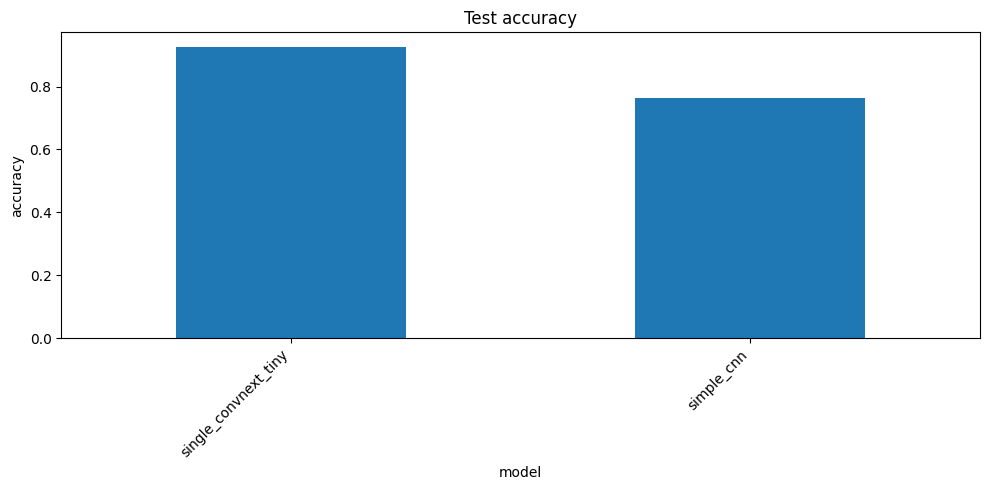

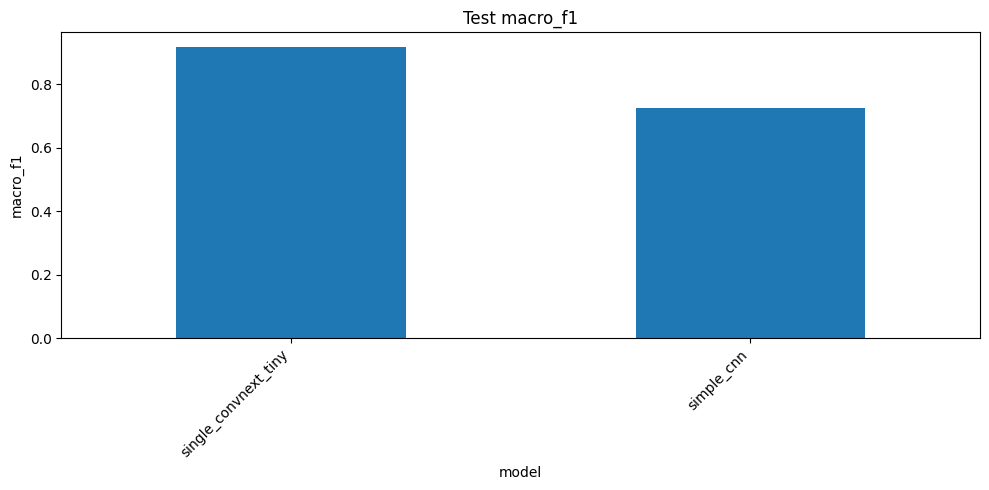

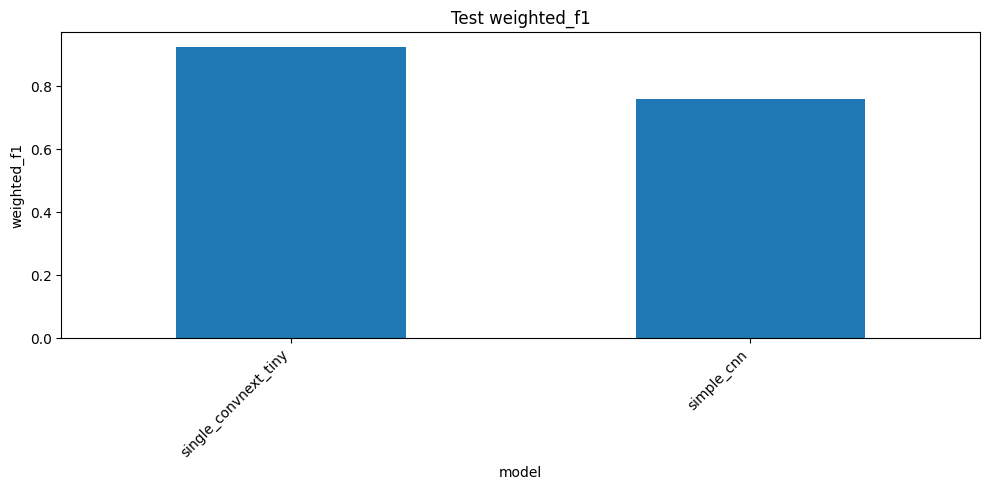

In [11]:
# ============================================================
# 11. PLOT COMPARISON
# ============================================================

plot_df = combined_df.copy()
if not plot_df.empty and 'model_name' in plot_df.columns:
    for metric in ['accuracy', 'macro_f1', 'weighted_f1']:
        if metric not in plot_df.columns:
            continue
        ax = plot_df.plot(kind='bar', x='model_name', y=metric, figsize=(10, 5), legend=False)
        ax.set_title(f'Test {metric}')
        ax.set_ylabel(metric)
        ax.set_xlabel('model')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


In [12]:
# ============================================================
# 12. SINGLE IMAGE INFERENCE FOR BASELINE MODELS
# ============================================================

@torch.no_grad()
def predict_single_image_baseline(image_path, model_name, topk=5):
    img_size = IMG_SIZE_BY_MODEL[model_name]
    _, eval_tf = get_transforms(img_size)

    ckpt_path = OUTPUT_DIR / f'best_{model_name}.pth'
    assert ckpt_path.exists(), f'Missing checkpoint: {ckpt_path}'

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model = MODEL_BUILDERS[model_name](ckpt['num_classes'], DROPOUT).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    img = Image.open(image_path).convert('RGB')
    x = eval_tf(img).unsqueeze(0).to(DEVICE)

    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    top_idx = probs.argsort()[-topk:][::-1]
    results = []
    for idx in top_idx:
        results.append({
            'rank': len(results) + 1,
            'class': ckpt['class_names'][idx],
            'probability': float(probs[idx]),
        })

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{model_name}: {results[0]['class']} ({results[0]['probability']:.1%})")
    plt.show()

    del model
    torch.cuda.empty_cache()

    return pd.DataFrame(results)

# Ví dụ:
# predict_single_image_baseline('/kaggle/input/my-food-image/pho.jpg', 'single_effb0', topk=5)


In [13]:
# ============================================================
# TEST ALL REALISTIC IMAGES WITH ALL BASELINE MODELS
# ============================================================

REALISTIC_DIR = '/kaggle/input/datasets/vhutin/realistic-test-food-image/Testing_realistic_image'

image_files = [
    'banh_beo.jpg',
    'banh_chung.png',
    'banh_cuon.png',
    'cha_ca_la_vong.png',
    'khau_nhuc.png',
    'pho_bo.png',
    'rau_muong_xao.png',
    'tau_hu_non.png',
    'trung_vit_lon.png',
]

baseline_models = [
    'single_effb0',
    'single_effb2',
    'single_convnext_tiny',
    'simple_cnn',
]

all_results = []

for model_name in baseline_models:

    print('\n' + '='*70)
    print(f'TESTING MODEL: {model_name}')
    print('='*70)

    for img_name in image_files:

        img_path = f'{REALISTIC_DIR}/{img_name}'

        print(f'\nImage: {img_name}')

        result = predict_single_image_baseline(
            img_path,
            model_name,
            topk=5
        )

        all_results.append({
            'model': model_name,
            'image': img_name,
            'predicted_class': result['predicted_class'],
            'confidence': result['confidence'],
        })


TESTING MODEL: single_effb0

Image: banh_beo.jpg


KeyError: 'single_effb0'

In [ ]:
import pandas as pd

results_df = pd.DataFrame(all_results)

csv_path = '/kaggle/working/realistic_image_results.csv'
xlsx_path = '/kaggle/working/realistic_image_results.xlsx'

results_df.to_csv(csv_path, index=False)
results_df.to_excel(xlsx_path, index=False)

print('\nSaved results:')
print(csv_path)
print(xlsx_path)

display(results_df)

## Ghi chú diễn giải kết quả

Để chứng minh hierarchical hợp lý hơn, bạn nên so sánh trên **test set** theo các chỉ số:

- `accuracy`
- `macro_f1`: quan trọng nếu dataset lệch class
- `weighted_f1`: phản ánh performance tổng thể theo phân bố data

Nếu hierarchical có `macro_f1` tốt hơn single EfficientNet-B0/B2, điều đó hỗ trợ luận điểm rằng chia bài toán thành group trước rồi phân loại class con giúp model học tốt hơn trên các nhóm món ăn phức tạp hoặc long-tail classes.
